In [1]:
from copy import deepcopy
from scipy import stats
from scipy.spatial import cKDTree
import pandas as pd
import os
import numpy as np
from tqdm import tqdm
import networkx as nx
import random
from collections import defaultdict, Counter
from typing import Dict, List, Set, Tuple, Optional
from itertools import chain, product
import bisect
from collections import defaultdict
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
seed = 0 # 1729928109

# Set the random seed for reproducibility
random.seed(seed)
np.random.seed(seed)

base_sparsified_path = r'/raid/t2/TGN_adv/sparsified_data'
dataset_name = 'mooc'

is_bipartite = True

if dataset_name.lower() in ['wikipedia', 'mooc']:
    is_bipartite = True
else:
    is_bipartite=False

original_filename = rf'ml_{dataset_name}.csv'

print(os.path.join(base_sparsified_path, dataset_name, original_filename))

orig_df = pd.read_csv(os.path.join(base_sparsified_path, dataset_name, original_filename))
orig_df.drop(['Unnamed: 0'], axis=1, inplace=True)
orig_df.head()

/raid/t2/TGN_adv/sparsified_data/mooc/ml_mooc.csv


,u,i,ts,label,idx
0,1,7048,0.0,0.0,1
1,1,7049,6.0,0.0,2
2,1,7050,41.0,0.0,3
3,1,7049,49.0,0.0,4
4,1,7050,51.0,0.0,5


In [2]:
# sparsification 
attack_path = r'/raid/t2/TGN_adv/poisoned_data'
sprs_type = 'ts_tpr_remove_mss'
upto = 0.7

# modified_wikipedia_ts_tpr_remove_mss_sparsified_0.7.csv
sprs_filename = f'{dataset_name}_{sprs_type}_sparsified_{upto}.csv'
sprs_filename

full_sprs_filepath = os.path.join(attack_path, dataset_name, sprs_type, sprs_filename)

att_df = pd.read_csv(full_sprs_filepath)
att_df.drop(['Unnamed: 0', 'Unnamed: 0.1'], axis=1, inplace=True)
att_df.head()

,u,i,ts,label,idx,adv
0,1,7048,0.000000,0.0,1.0,0
1,6,7049,38300.461146,NaN,NaN,1
2,6,7051,38824.286304,NaN,NaN,1
3,13,7056,39104.668954,NaN,NaN,1
4,13,7049,39104.668954,NaN,NaN,1


In [3]:
val_ratio = test_ratio = 0.15

val_time, test_time = list(np.quantile(orig_df.ts, [(1 - val_ratio - test_ratio), (1 - test_ratio)]))

orig_df = orig_df[orig_df['ts'] < val_time]
att_df = att_df[att_df['ts'] < val_time]

## Utils

In [4]:
from collections import defaultdict


def optimize_c3_checking(df, time_window=1200*1e3):
    """Precompute node appearance windows for faster C3 checking"""
    df_sorted = df.sort_values('ts')
    
    # Precompute node appearances
    node_appearances = defaultdict(list)
    for _, row in df_sorted.iterrows():
        node_appearances[row['u']].append(row['ts'])
        node_appearances[row['i']].append(row['ts'])
    
    # Sort appearances for binary search
    for node in node_appearances:
        node_appearances[node] = np.array(sorted(node_appearances[node]))
    
    return node_appearances

def fast_check_c3_compliance(node_appearances, negative_samples, time_window=1200*1e3):
    """
    Fast C3 compliance checking using binary search
    
    Args:
        node_appearances: Dict mapping nodes to sorted arrays of their timestamps
        negative_samples: List/array of (u, i, ts) tuples to check
        time_window: Time window size
    """
    compliant = []
    
    for u, i, ts in negative_samples:
        # Check source node
        u_times = node_appearances.get(u, [])
        if len(u_times) == 0:
            compliant.append(False)
            continue
            
        # Binary search for window start in u's appearances
        window_start = ts - time_window
        u_idx = np.searchsorted(u_times, window_start)
        if u_idx >= len(u_times) or u_times[u_idx] > ts:
            compliant.append(False)
            continue
            
        # Check destination node
        i_times = node_appearances.get(i, [])
        if len(i_times) == 0:
            compliant.append(False)
            continue
            
        # Binary search for window start in i's appearances
        i_idx = np.searchsorted(i_times, window_start)
        if i_idx >= len(i_times) or i_times[i_idx] > ts:
            compliant.append(False)
            continue
            
        compliant.append(True)
        
    return compliant

def check_c3_compliance_optimized(df, negative_samples, time_window=1200*1e3):
    """Wrapper for optimized C3 checking"""
    # Precompute once
    node_appearances = optimize_c3_checking(df, time_window)
    
    # Check compliance
    return fast_check_c3_compliance(node_appearances, negative_samples, time_window)

In [5]:
def plot_degree_comparison(df1, df2, src_col='u', dst_col='i'):
    """
    Visualize degree distribution comparison between two DataFrames
    """
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    
    # Calculate degree distributions
    src_degrees1 = Counter(df1[src_col])
    dst_degrees1 = Counter(df1[dst_col])
    src_degrees2 = Counter(df2[src_col])
    dst_degrees2 = Counter(df2[dst_col])
    
    # Plot 1: Source Node Degree Distribution
    degrees1 = list(src_degrees1.values())
    degrees2 = list(src_degrees2.values())
    ax1.hist([degrees1, degrees2], label=['Original', 'Generated'], 
             alpha=0.6, bins=30)
    ax1.set_title('Source Node Degree Distribution')
    ax1.set_xlabel('Degree')
    ax1.set_ylabel('Count')
    ax1.legend()
    
    # Plot 2: Destination Node Degree Distribution
    degrees1 = list(dst_degrees1.values())
    degrees2 = list(dst_degrees2.values())
    ax2.hist([degrees1, degrees2], label=['Original', 'Generated'], 
             alpha=0.6, bins=30)
    ax2.set_title('Destination Node Degree Distribution')
    ax2.set_xlabel('Degree')
    ax2.set_ylabel('Count')
    ax2.legend()
    
    # Plot 3: Source Node Degree Scatter
    x = sorted(set(src_degrees1.keys()) | set(src_degrees2.keys()))
    y1 = [src_degrees1.get(k, 0) for k in x]
    y2 = [src_degrees2.get(k, 0) for k in x]
    ax3.scatter(y1, y2, alpha=0.5)
    ax3.plot([0, max(max(y1), max(y2))], [0, max(max(y1), max(y2))], 'r--')
    ax3.set_title('Source Node Degree Comparison')
    ax3.set_xlabel('Original Degree')
    ax3.set_ylabel('Generated Degree')
    
    # Plot 4: Destination Node Degree Scatter
    x = sorted(set(dst_degrees1.keys()) | set(dst_degrees2.keys()))
    y1 = [dst_degrees1.get(k, 0) for k in x]
    y2 = [dst_degrees2.get(k, 0) for k in x]
    ax4.scatter(y1, y2, alpha=0.5)
    ax4.plot([0, max(max(y1), max(y2))], [0, max(max(y1), max(y2))], 'r--')
    ax4.set_title('Destination Node Degree Comparison')
    ax4.set_xlabel('Original Degree')
    ax4.set_ylabel('Generated Degree')
    
    plt.tight_layout()
    plt.savefig("BP_degree_dist.pdf", format="pdf", bbox_inches="tight")
    plt.show()
    
    # Additional statistics
    src_corr = np.corrcoef(
        [src_degrees1.get(k, 0) for k in x],
        [src_degrees2.get(k, 0) for k in x]
    )[0,1]
    dst_corr = np.corrcoef(
        [dst_degrees1.get(k, 0) for k in x],
        [dst_degrees2.get(k, 0) for k in x]
    )[0,1]
    
    print(f"Source degree correlation: {src_corr:.3f}")
    print(f"Destination degree correlation: {dst_corr:.3f}")

def plot_degree_comparison_nonbipartite(df1, df2, node_cols=['u', 'i']):
    """
    Visualize degree distribution comparison between two DataFrames for non-bipartite graphs
    
    Parameters:
    -----------
    df1, df2 : pandas.DataFrame
        DataFrames containing edge information
    node_cols : list
        Column names containing node IDs (default ['u', 'i'])
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Calculate unified degree distributions
    def get_degree_dist(df):
        degrees = Counter()
        for col in node_cols:
            degrees.update(Counter(df[col]))
        return degrees
    
    degrees1 = get_degree_dist(df1)
    degrees2 = get_degree_dist(df2)
    
    # Plot 1: Overall Node Degree Distribution
    degree_values1 = list(degrees1.values())
    degree_values2 = list(degrees2.values())
    
    ax1.hist([degree_values1, degree_values2], 
             label=['Original', 'Generated'], 
             alpha=0.6, bins=30)
    ax1.set_title('Node Degree Distribution')
    ax1.set_xlabel('Degree')
    ax1.set_ylabel('Count')
    ax1.set_yscale('log')  # Log scale for better visualization
    ax1.legend()
    
    # Plot 2: Degree Comparison Scatter
    x = sorted(set(degrees1.keys()) | set(degrees2.keys()))
    y1 = [degrees1.get(k, 0) for k in x]
    y2 = [degrees2.get(k, 0) for k in x]
    
    # y2 = [val2 if val1 == val2 else val2 for val1, val2 in zip(y1, y2)]


    
    
    ax2.scatter(y1, y2, alpha=0.5)
    ax2.plot([0, max(max(y1), max(y2))], [0, max(max(y1), max(y2))], 'r--')
    ax2.set_title('Node Degree Comparison')
    ax2.set_xlabel('Original Degree')
    ax2.set_ylabel('Generated Degree')
    ax2.set_xscale('log')  # Log scale for better visualization
    ax2.set_yscale('log')
    
    plt.tight_layout()
    # plt.savefig("NonBP_degree_dist.pdf", format="pdf", bbox_inches="tight")
    plt.show()
    
    # Additional statistics
    degree_corr = np.corrcoef(y1, y2)[0,1]
    
    # Calculate degree statistics
    def degree_stats(degrees):
        values = list(degrees.values())
        return {
            'mean': np.mean(values),
            'median': np.median(values),
            'std': np.std(values),
            'max': max(values),
            'min': min(values)
        }
    
    stats1 = degree_stats(degrees1)
    stats2 = degree_stats(degrees2)
    
    print("\nDegree Distribution Statistics:")
    print(f"Degree correlation: {degree_corr:.3f}")
    print("\nOriginal Graph:")
    for k, v in stats1.items():
        print(f"{k}: {v:.2f}")
    print("\nGenerated Graph:")
    for k, v in stats2.items():
        print(f"{k}: {v:.2f}")
    
    # Calculate KL divergence for degree distributions
    def calculate_kl_divergence(p, q):
        # Normalize distributions
        p_sum = sum(p)
        q_sum = sum(q)
        p_norm = [x/p_sum for x in p]
        q_norm = [x/q_sum for x in q]
        
        # Add small constant to avoid division by zero
        epsilon = 1e-10
        p_norm = [x + epsilon for x in p_norm]
        q_norm = [x + epsilon for x in q_norm]
        
        return sum(p * np.log(p/q) for p, q in zip(p_norm, q_norm))
    
    kl_div = calculate_kl_divergence(np.array(y1), np.array(y2))
    print(f"\nKL Divergence: {kl_div:.3f}")

## Runs

In [6]:
missing_edges = orig_df[['u', 'i', 'ts']]
new_edges  = list(att_df[['u', 'i', 'ts']].itertuples(index=False, name=None))  # att_df[['u', 'i', 'ts']]
print("Missing Edges: ",len(missing_edges))
print("New Edge: ",len(new_edges))
print("Edges Difference: ",len(missing_edges)-len(new_edges))

Missing Edges:  288224
New Edge:  287717
Edges Difference:  507


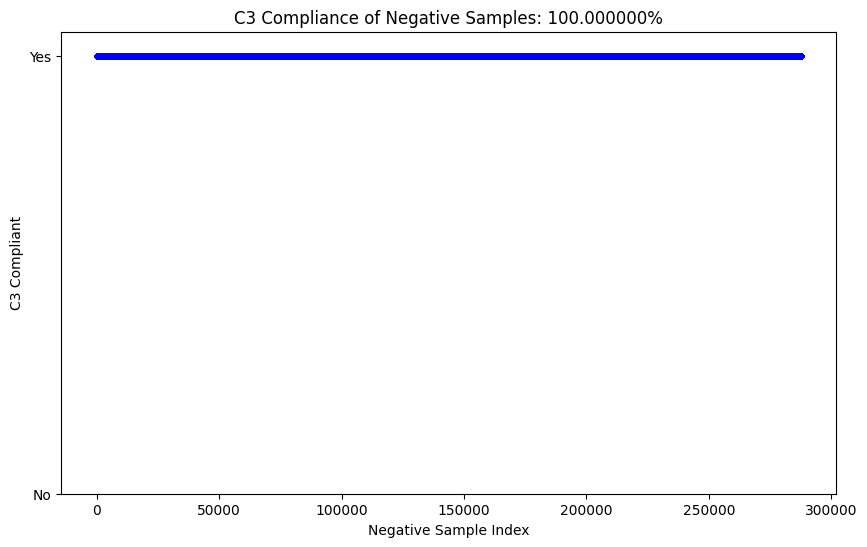

In [7]:
compliant = check_c3_compliance_optimized(missing_edges, new_edges)

plt.figure(figsize=(10, 6))
plt.plot(range(len(compliant)), compliant, 'b.')
plt.xlabel('Negative Sample Index')
plt.ylabel('C3 Compliant')
plt.title(f'C3 Compliance of Negative Samples: {sum(compliant)/len(compliant):.6%}')
plt.yticks([0, 1], ['No', 'Yes'])
plt.savefig("C3_Compliant.pdf", format="pdf", bbox_inches="tight")
plt.show()

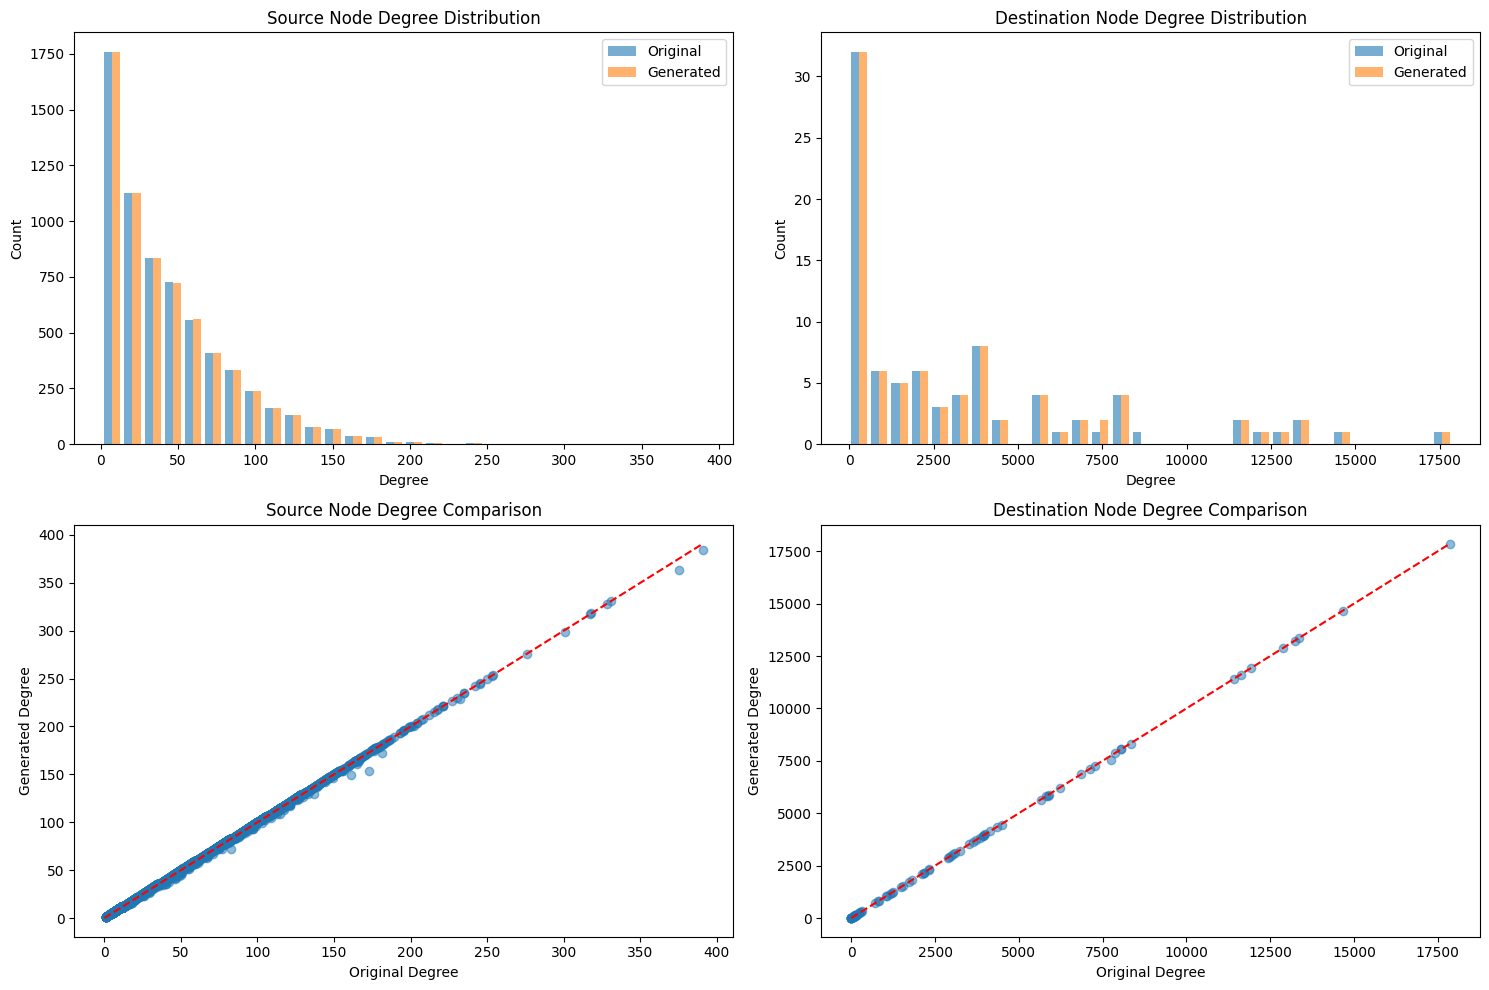

Source degree correlation: nan
Destination degree correlation: 1.000


In [8]:
if is_bipartite:
    plot_degree_comparison(missing_edges, att_df)
else:
    plot_degree_comparison_nonbipartite(missing_edges, att_df)

## Check Attack

In [10]:
att_df.head()

,u,i,ts,label,idx,adv
0,1,7048,0.000000,0.0,1.0,0
1,6,7049,38300.461146,NaN,NaN,1
2,6,7051,38824.286304,NaN,NaN,1
3,13,7056,39104.668954,NaN,NaN,1
4,13,7049,39104.668954,NaN,NaN,1


In [11]:
att_df['adv'].unique()

array([0, 1])